#**DATA IMPORTING AND READING**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\susha\Downloads\spotify_user_behavior_realistic_50000_rows.csv")

In [3]:
df.isnull().sum()

user_id                           0
country                           0
age                               0
signup_date                       0
subscription_type                 0
subscription_status               0
months_inactive                   0
inactive_3_months_flag            0
ad_interaction                    0
ad_conversion_to_subscription     0
music_suggestion_rating_1_to_5    0
avg_listening_hours_per_week      0
favorite_genre                    0
most_liked_feature                0
desired_future_feature            0
primary_device                    0
playlists_created                 0
avg_skips_per_day                 0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   user_id                         50000 non-null  int64  
 1   country                         50000 non-null  object 
 2   age                             50000 non-null  int64  
 3   signup_date                     50000 non-null  object 
 4   subscription_type               50000 non-null  object 
 5   subscription_status             50000 non-null  object 
 6   months_inactive                 50000 non-null  int64  
 7   inactive_3_months_flag          50000 non-null  int64  
 8   ad_interaction                  50000 non-null  object 
 9   ad_conversion_to_subscription   50000 non-null  object 
 10  music_suggestion_rating_1_to_5  50000 non-null  int64  
 11  avg_listening_hours_per_week    50000 non-null  float64
 12  favorite_genre                  

In [5]:
df.head()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,No,No,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,Yes,No,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,Yes,Yes,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,No,No,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,No,No,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


#**DATA CLEANING AND PRE-PROCESSING**

In [6]:
# Changing data type of signup_date column from object to datetime format
df['signup_date'] = pd.to_datetime(df['signup_date'])

print(df['signup_date'].dtypes)

datetime64[ns]


In [7]:
#Change the following column's data and their data types
cols = ['ad_interaction', 'ad_conversion_to_subscription']

for col in cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0}).astype('int64')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   user_id                         50000 non-null  int64         
 1   country                         50000 non-null  object        
 2   age                             50000 non-null  int64         
 3   signup_date                     50000 non-null  datetime64[ns]
 4   subscription_type               50000 non-null  object        
 5   subscription_status             50000 non-null  object        
 6   months_inactive                 50000 non-null  int64         
 7   inactive_3_months_flag          50000 non-null  int64         
 8   ad_interaction                  50000 non-null  int64         
 9   ad_conversion_to_subscription   50000 non-null  int64         
 10  music_suggestion_rating_1_to_5  50000 non-null  int64         
 11  av

## **Task 1 - Count users by subscription type**

In [9]:
subscription_count = df['subscription_type'].value_counts()
print(subscription_count)

subscription_type
Free                  22525
Premium Individual    14029
Student                4516
Premium Family         4482
Premium Duo            4448
Name: count, dtype: int64


In [10]:
subscription_percentage = subscription_percentage = df['subscription_type'].value_counts(normalize=True).mul(100).round(1)
print(subscription_percentage)

subscription_type
Free                  45.1
Premium Individual    28.1
Student                9.0
Premium Family         9.0
Premium Duo            8.9
Name: proportion, dtype: float64


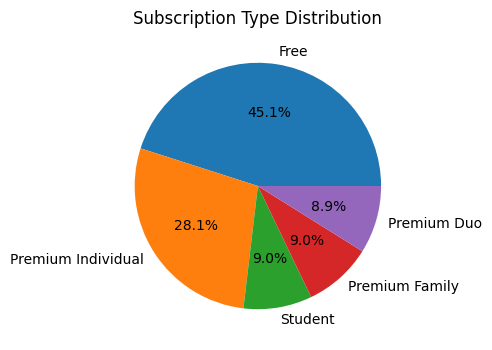

In [11]:
plt.figure(figsize = (6,4))
plt.pie(subscription_percentage,
        labels=subscription_percentage.index,
        autopct='%1.1f%%')

plt.title('Subscription Type Distribution')
plt.show()

## **Task 2 - Country-wise User Engagement**

In [12]:
df.head()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,0,0,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,1,0,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,1,1,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,0,0,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,0,0,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


In [13]:
#Average listening hours per country (Top 5)
country_engagement = df.groupby('country')['avg_listening_hours_per_week'].mean().sort_values(ascending=False)

top_5_countries = country_engagement.head(5)
print(top_5_countries)


country
Indonesia    10.053466
Spain        10.048019
USA          10.041402
Brazil       10.039238
Mexico       10.023082
Name: avg_listening_hours_per_week, dtype: float64


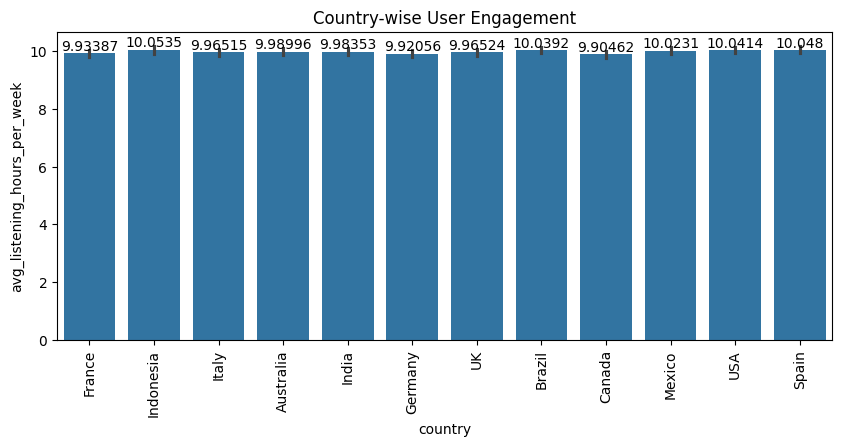

In [14]:
plt.figure(figsize = (10,4))
ax = sns.barplot(x='country',y='avg_listening_hours_per_week',data = df)
ax.bar_label(ax.containers[0])

plt.xticks(rotation = 90)
plt.title('Country-wise User Engagement')
plt.show()

## **Task 3 - Genre Popularity Analysis**

In [15]:
df.head()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,0,0,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,1,0,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,1,1,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,0,0,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,0,0,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11


favorite_genre
Classical     4272
Bollywood     4246
K-Pop         4228
Latin         4203
Indie         4182
Electronic    4144
Country       4135
Jazz          4134
Hip-Hop       4125
Rock          4120
Name: count, dtype: int64


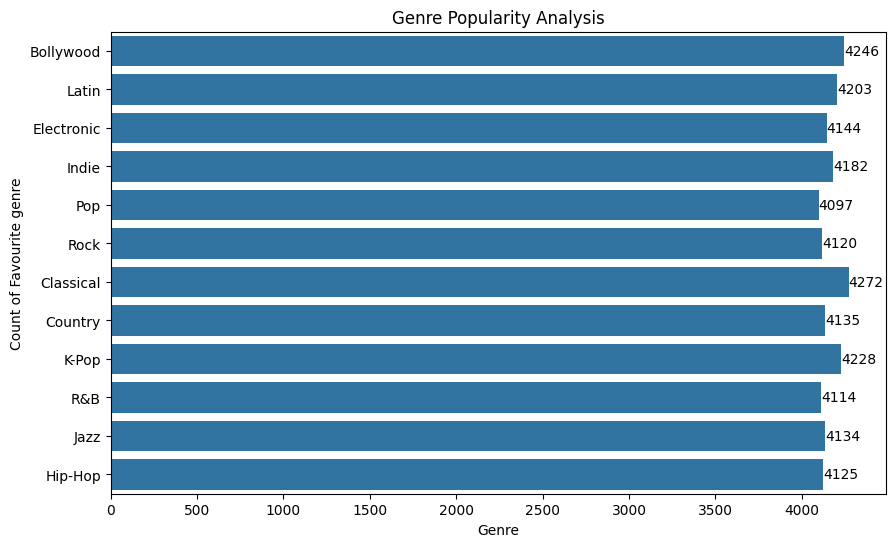

In [16]:
# Most popular Genre
genre_counts = df['favorite_genre'].value_counts()

print(genre_counts.head(10))

plt.figure(figsize=(10,6))
ax = sns.countplot(y='favorite_genre',data = df)
ax.bar_label(ax.containers[0])
plt.title('Genre Popularity Analysis')
plt.xlabel('Genre')
plt.ylabel('Count of Favourite genre')
plt.show()

## **Task 4 - Churn Analysis**

In [17]:
df.head(10)

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,0,0,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,1,0,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,1,1,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,0,0,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8
4,5,Australia,18,2020-05-29,Free,Active,0,0,0,0,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11
5,6,France,43,2018-12-19,Premium Duo,Active,0,0,0,0,4,12.51,Electronic,AI DJ,Better AI Recommendations,Car System,3,10
6,7,Italy,21,2022-09-09,Student,Active,3,1,1,1,4,8.61,Bollywood,Daily Mix,HiFi Audio,Tablet,13,8
7,8,India,43,2024-03-07,Free,Active,1,0,0,0,5,8.14,Pop,Daily Mix,Social Listening,Mobile,5,16
8,9,Germany,52,2018-08-31,Premium Family,Active,2,0,0,0,5,7.53,Latin,Discover Weekly,Concert Alerts,Mobile,10,21
9,10,India,56,2019-05-23,Premium Duo,Active,1,0,1,0,5,8.55,Rock,Playlists,Mood-based Auto Playlists,Tablet,12,17


In [18]:
df['churn'] = df['months_inactive'].apply(lambda x: 1 if x >= 3 else 0)

churn_rate = df['churn'].mean() * 100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 22.25%


## **Task 5 - Device Usage Analysis**

primary_device
Smart Speaker    10050
Car System       10044
Desktop          10037
Mobile            9937
Tablet            9932
Name: count, dtype: int64


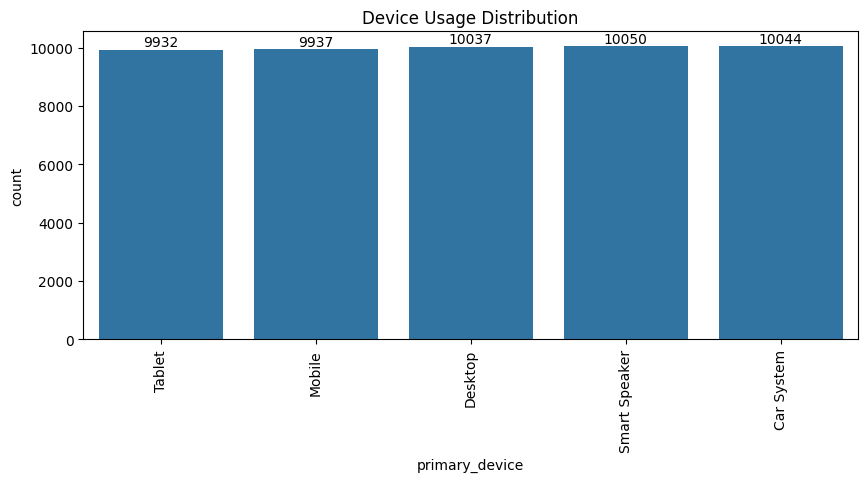

In [19]:
device_usage = df['primary_device'].value_counts()

print(device_usage)

plt.figure(figsize = (10,4))
ax = sns.countplot(x='primary_device',data = df)
ax.bar_label(ax.containers[0])

plt.xticks(rotation = 90)
plt.title('Device Usage Distribution')
plt.show()

## **Task 6 - Correlation Analysis**

In [20]:
correlation = df[['avg_listening_hours_per_week', 'avg_skips_per_day']].corr()

print(correlation)

                              avg_listening_hours_per_week  avg_skips_per_day
avg_listening_hours_per_week                      1.000000           0.006923
avg_skips_per_day                                 0.006923           1.000000


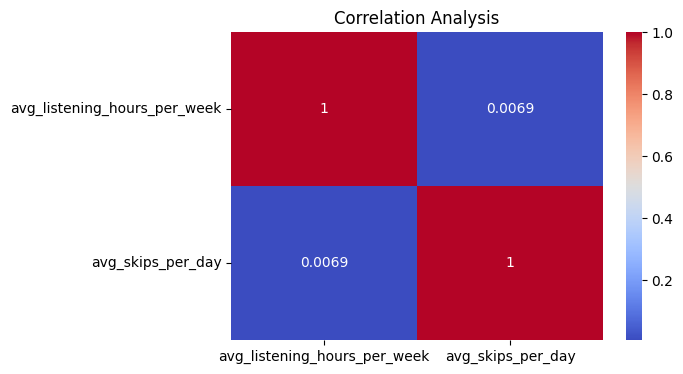

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Analysis')
plt.show()

## **Task 7 - Ad Conversion Analysis**

In [22]:
df.head()

,user_id,country,age,signup_date,subscription_type,subscription_status,months_inactive,inactive_3_months_flag,ad_interaction,ad_conversion_to_subscription,music_suggestion_rating_1_to_5,avg_listening_hours_per_week,favorite_genre,most_liked_feature,desired_future_feature,primary_device,playlists_created,avg_skips_per_day,churn
0,1,France,25,2021-08-19,Premium Duo,Active,0,0,0,0,4,10.13,Bollywood,Radio,Concert Alerts,Tablet,7,8,0
1,2,Indonesia,20,2022-06-06,Premium Family,Active,0,0,1,0,5,11.63,Latin,Podcasts,Lyrics Translation,Mobile,7,6,0
2,3,Italy,53,2024-01-04,Premium Individual,Active,0,0,1,1,3,9.50,Bollywood,Lyrics,Better AI Recommendations,Desktop,6,5,0
3,4,Italy,48,2018-08-26,Premium Individual,Active,1,0,0,0,4,13.16,Electronic,Playlists,Social Listening,Smart Speaker,11,8,0
4,5,Australia,18,2020-05-29,Free,Active,0,0,0,0,4,12.70,Indie,Daily Mix,Lyrics Translation,Tablet,10,11,0


In [23]:
conversion_rate = df.groupby('ad_interaction')['ad_conversion_to_subscription'].mean()

print(conversion_rate)

ad_interaction
0    0.000000
1    0.248885
Name: ad_conversion_to_subscription, dtype: float64


## **Task 8 - Listening hours distribution**

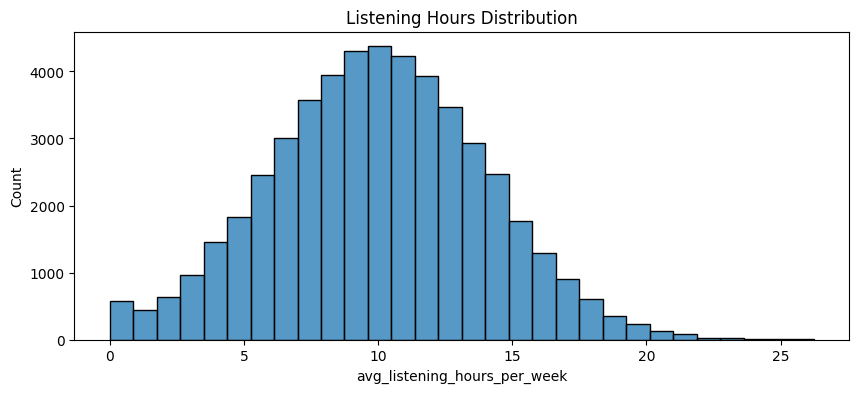

In [24]:
plt.figure(figsize=(10,4))
sns.histplot(df['avg_listening_hours_per_week'], bins=30)
plt.title("Listening Hours Distribution")
plt.show()

## **Task 9 - Age vs listening hours per week**

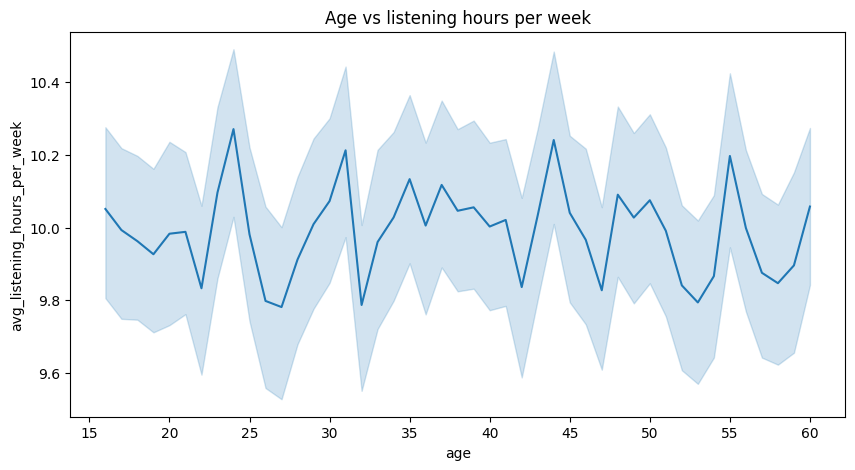

In [25]:
plt.figure(figsize=(10,5))
sns.lineplot(x='age',y='avg_listening_hours_per_week',data=df)
plt.title('Age vs listening hours per week')
plt.xticks(range(15, 65, 5))
plt.show()

## **Task 10 - Music suggestion rating Distribution**

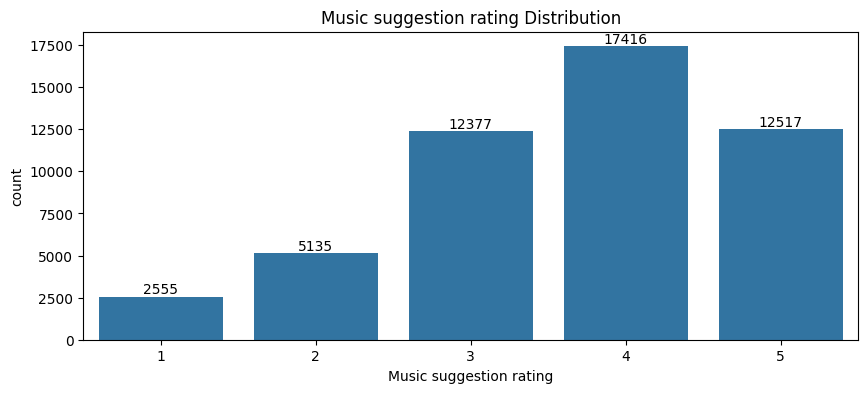

In [26]:
plt.figure(figsize = (10,4))
ax = sns.countplot(x='music_suggestion_rating_1_to_5',data = df)
ax.bar_label(ax.containers[0])
plt.title('Music suggestion rating Distribution')
plt.xlabel('Music suggestion rating')
plt.show()